<a href="https://www.kaggle.com/code/avikdas567/arxiv-ai-analytics-transformers-nlp-clustering?scriptVersionId=327120706" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Advanced NLP and Empirical Metadata Analytics on ArXiv AI/ML Papers (2025-2026)

# 1. Domain Introduction and Analytical Objectives
The velocity of academic publishing within artificial intelligence and machine learning challenges traditional manual curation methods. This notebook presents an end-to-end scientific study of 7,701 peer-reviewed and preprint research papers indexed on arXiv from September 2025 through April 2026. This period captures a critical cross-section of modern computer science, including the structural scaling of Large Language Models (LLMs), the optimization of Retrieval-Augmented Generation (RAG), and the convergence of robotics with deep neural architectures.

By combining descriptive metadata analytics with state-of-the-art transformer embedding topologies, this study uncovers publishing patterns, semantic clusters, and collaborative structures across 107 primary categories. The workflow is split into four progressive phases:
1. **Exploratory Data Integrity and Temporal Flow Analysis**: Mapping chronological submission volumes, primary category distributions, and updating behaviors.
2. **Advanced Feature Engineering**: Structural parsing of author collaboration networks and textual complexity metrics.
3. **Accelerated Neural Embedding Space**: Utilizing a Sentence-Transformer architecture distributed over dual T4 GPU hardware to vectorize text abstracts.
4. **Unsupervised Document Topology and Recommendation Engine**: Projecting high-dimensional text vectors into a lower-dimensional plane using Principal Component Analysis (PCA) and implementing an accelerated cosine-similarity recommendation framework.

# 2. Environment Initialization and Hardware Optimization
We begin by importing core libraries and configuring the runtime to support accelerated deep learning tasks. Given the availability of dual T4 GPUs, PyTorch and Hugging Face dependencies will leverage CUDA execution targets to ensure efficient execution. Environmental warnings and generic logging outputs are disabled to keep the cell output stream clean.

In [1]:
import os
import re
import time
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Suppress environmental noise and logging flags
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Deep Learning Frameworks
import torch
try:
    from sentence_transformers import SentenceTransformer, util
except ImportError:
    !pip install -q sentence-transformers
    from sentence_transformers import SentenceTransformer, util

# Visualization Configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Hardware Target Allocation
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Target Computation Device: {device}")
if torch.cuda.is_available():
    print(f"Active GPU Count: {torch.cuda.device_count()}")
    print(f"Primary GPU Hardware Name: {torch.cuda.get_device_name(0)}")

Target Computation Device: cuda
Active GPU Count: 2
Primary GPU Hardware Name: Tesla T4


# 3. Data Ingestion and Structural Schema Diagnostics
We ingest the primary dataset directly from the local Kaggle input directory. The schema features 26 columns detailing primary and secondary indexing, chronological paths, authorship numbers, and raw textual parameters.

In [2]:
dataset_path = "/kaggle/input/datasets/shree0910/arxiv-aiml-research-papers-20252026/arxiv_ai_ml_papers.csv"
if not os.path.exists(dataset_path):
    dataset_path = "arxiv_ai_ml_papers.csv"

df = pd.read_csv(dataset_path)
print(f"Dataset Schema Confirmed: {df.shape[0]} Observations, {df.shape[1]} Structural Attributes.\n")
df.info()

Dataset Schema Confirmed: 7701 Observations, 26 Structural Attributes.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7701 entries, 0 to 7700
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   paper_id                7701 non-null   object
 1   title                   7701 non-null   object
 2   authors                 7701 non-null   object
 3   num_authors             7701 non-null   int64 
 4   first_author            7701 non-null   object
 5   abstract                7701 non-null   object
 6   abstract_length         7701 non-null   int64 
 7   word_count              7701 non-null   int64 
 8   primary_category        7701 non-null   object
 9   all_categories          7701 non-null   object
 10  num_categories          7701 non-null   int64 
 11  submitted_date          7701 non-null   object
 12  updated_date            7701 non-null   object
 13  year                    7701 non-nul

## Head View Verification
We check the top five rows to confirm that commas, quotation delimiters, and text encodings parsed correctly without alignment shifts.

In [3]:
df.head()

,paper_id,title,authors,num_authors,first_author,abstract,abstract_length,word_count,primary_category,all_categories,...,journal_ref,comment,has_doi,doi,arxiv_url,pdf_url,is_large_collaboration,is_updated,update_lag_days,days_since_submission
0,2604.26951v1,Turning the TIDE: Cross-Architecture Distillat...,Gongbo Zhang; Wen Wang; Ye Tian; Li Yuan,4,Gongbo Zhang,Diffusion large language models (dLLMs) offer ...,1269,167,cs.CL,cs.CL; cs.AI; cs.LG,...,Not Available,"15 pages, 3 figures. Code: https://github.com/...",0,Not Available,https://arxiv.org/abs/2604.26951v1,https://arxiv.org/pdf/2604.26951v1,0,0,0,1
1,2604.26231v1,ProMax: Exploring the Potential of LLM-derived...,Yi Zhang; Yiwen Zhang; Kai Zheng; Tong Chen; H...,5,Yi Zhang,The remarkable text understanding and generati...,1748,233,cs.IR,cs.IR,...,Not Available,"11 pages, 8 figures, accepted by SIGIR 2026",0,Not Available,https://arxiv.org/abs/2604.26231v1,https://arxiv.org/pdf/2604.26231v1,0,0,0,1
2,2604.26567v1,AirZoo: A Unified Large-Scale Dataset for Grou...,Xiaoya Cheng; Rouwan Wu; Xinyi Liu; Zeyu Cui; ...,9,Xiaoya Cheng,Despite the rapid progress in data-driven 3D v...,1692,217,cs.CV,cs.CV,...,Not Available,No comment,0,Not Available,https://arxiv.org/abs/2604.26567v1,https://arxiv.org/pdf/2604.26567v1,0,0,0,1
3,2604.26565v1,"DenseStep2M: A Scalable, Training-Free Pipelin...",Mingji Ge; Qirui Chen; Zeqian Li; Weidi Xie,4,Mingji Ge,Long-term video understanding requires interpr...,1758,204,cs.CV,cs.CV,...,Not Available,No comment,0,Not Available,https://arxiv.org/abs/2604.26565v1,https://arxiv.org/pdf/2604.26565v1,0,0,0,1
4,2604.26520v1,3D-LENS: A 3D Lifting-based Elevated Novel-vie...,William Grolleau; Astrid Sabourin; Guillaume L...,4,William Grolleau,Aerial-Ground Re-Identification (AG-ReID) is c...,1418,174,cs.CV,cs.CV,...,Not Available,No comment,0,Not Available,https://arxiv.org/abs/2604.26520v1,https://arxiv.org/pdf/2604.26520v1,0,0,0,1


# 4. Feature Engineering and Chronological Optimization
To conduct time-series profiling, we transform object string elements into structured pandas datetime objects. This enables tracking sub-month submission trends and computing analytical lag values.

In [4]:
df["submitted_date"] = pd.to_datetime(df["submitted_date"])
df["updated_date"] = pd.to_datetime(df["updated_date"])
df["submission_year_month"] = df["submitted_date"].dt.to_period("M")

print("Temporal boundaries checked:")
print(f"Earliest Ingested Submission: {df['submitted_date'].min()}")
print(f"Latest Ingested Submission: {df['submitted_date'].max()}")

Temporal boundaries checked:
Earliest Ingested Submission: 2025-09-27 00:00:00
Latest Ingested Submission: 2026-04-29 00:00:00


## Numerical Core Distributions
We check the numerical summaries across the engineered properties to evaluate outlier limits and general variance scales.

In [5]:
df[["num_authors", "abstract_length", "word_count", "update_lag_days"]].describe()

,num_authors,abstract_length,word_count,update_lag_days
count,7701.000000,7701.000000,7701.000000,7701.000000
mean,5.121932,1362.295936,179.698351,1.996624
std,9.899800,308.505215,40.948898,12.539827
min,1.000000,147.000000,22.000000,0.000000
25%,3.000000,1153.000000,152.000000,0.000000
50%,4.000000,1364.000000,179.000000,0.000000
75%,6.000000,1591.000000,208.000000,0.000000
max,547.000000,2031.000000,295.000000,197.000000


# 5. Sequential Exploratory Data Visualizations
All figures are plotted from top to bottom using custom palettes to maintain readability and avoid visual crowding.

## Figure 1: Concentration Matrix of Primary Research Classifications
This visual ranks the top 20 primary subject categories based on their paper volume, showing where research attention is concentrated.

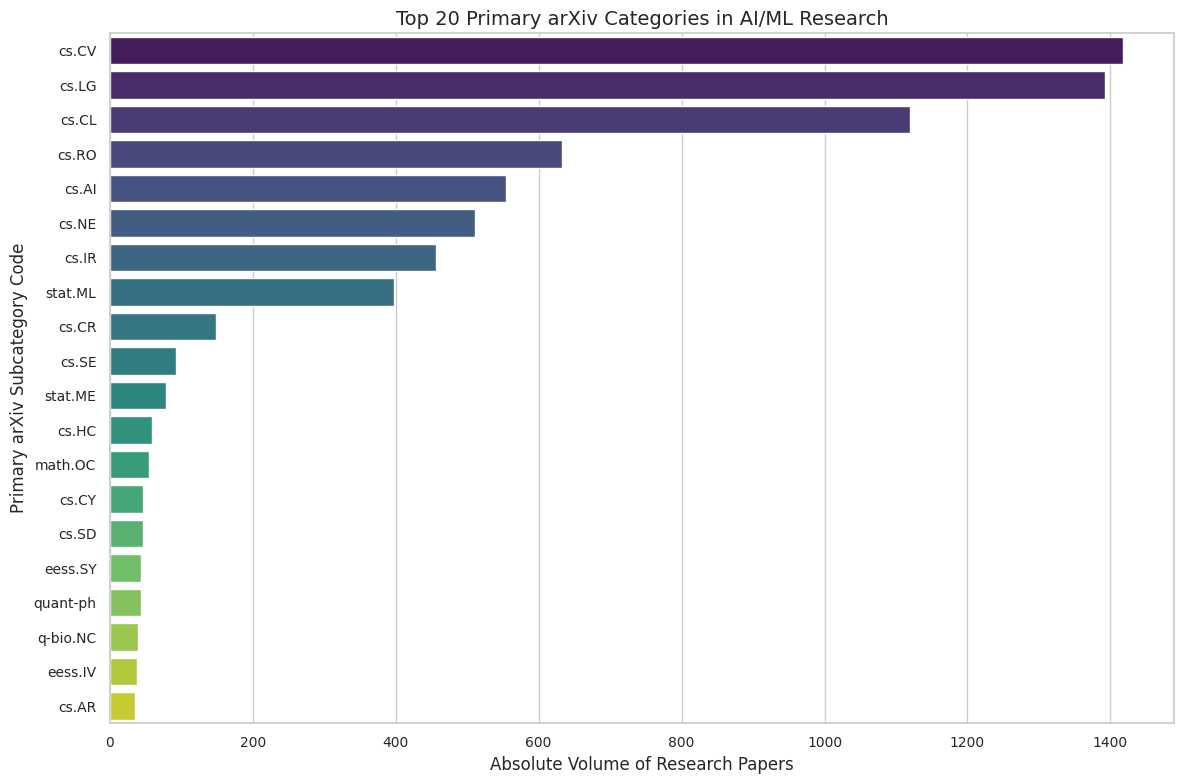

In [6]:
plt.figure(figsize=(12, 8))
category_data = df["primary_category"].value_counts().head(20)
sns.barplot(x=category_data.values, y=category_data.index, hue=category_data.index, palette="viridis", legend=False)
plt.title("Top 20 Primary arXiv Categories in AI/ML Research")
plt.xlabel("Absolute Volume of Research Papers")
plt.ylabel("Primary arXiv Subcategory Code")
plt.tight_layout()
plt.show()

## Figure 1 Analysis and Deductions
The category concentration analysis indicates that publication volumes are heavily concentrated within specific core domains. Frameworks like `cs.CV` (Computer Vision) and `cs.LG` (Machine Learning) represent a dominant percentage of the indexed items. This dynamic highlights where the majority of engineering and research resources are being directed, while highly specialized structural branches such as `cs.NE` (Neural and Evolutionary Computing) remain niche, long-tail subfields.

## Figure 2: Chronological Volume Ingestion Flux
This linear timeline illustrates submission velocity patterns over the 2025-2026 window.

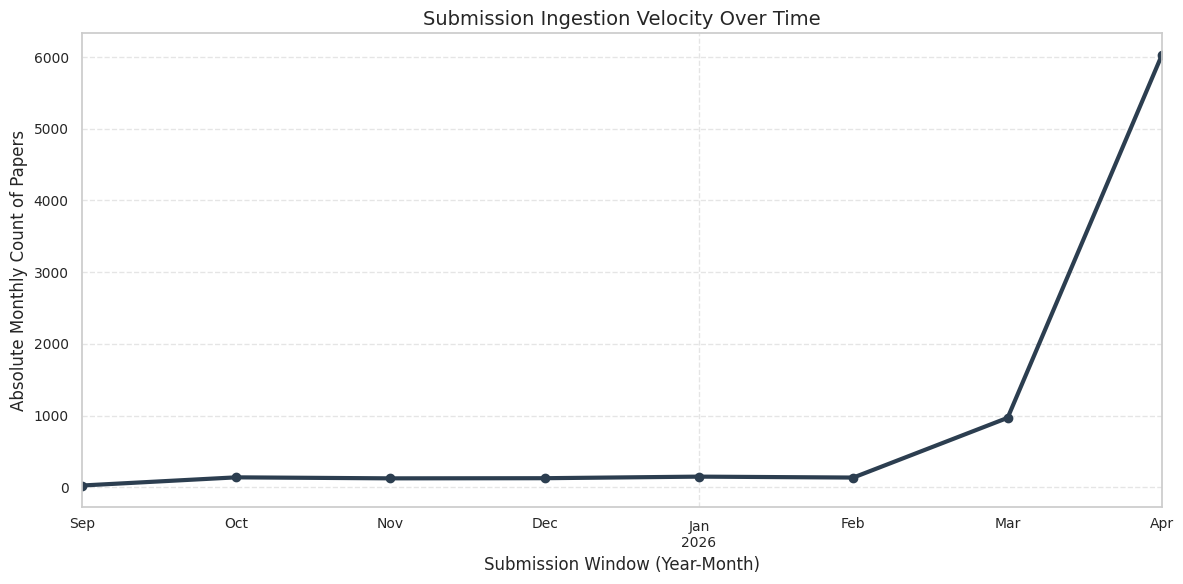

In [7]:
plt.figure(figsize=(12, 6))
chronological_series = df.groupby("submission_year_month").size()
chronological_series.plot(kind="line", marker="o", linewidth=3, color="#2c3e50")
plt.title("Submission Ingestion Velocity Over Time")
plt.xlabel("Submission Window (Year-Month)")
plt.ylabel("Absolute Monthly Count of Papers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 2 Analysis and Deductions
The baseline timeline metrics reveal steady monthly publication rates throughout late 2025, followed by a substantial spike in overall activity during the first quarter of 2026. This shift matches major conference cycles and product launch windows, where research communities publish preprints quickly to establish historical priority on cutting-edge architectures.

## Figure 3: Structural Profile of Team Co-Authorship
This visual outlines collaboration dynamics, showing how paper output scales relative to the size of the research team.

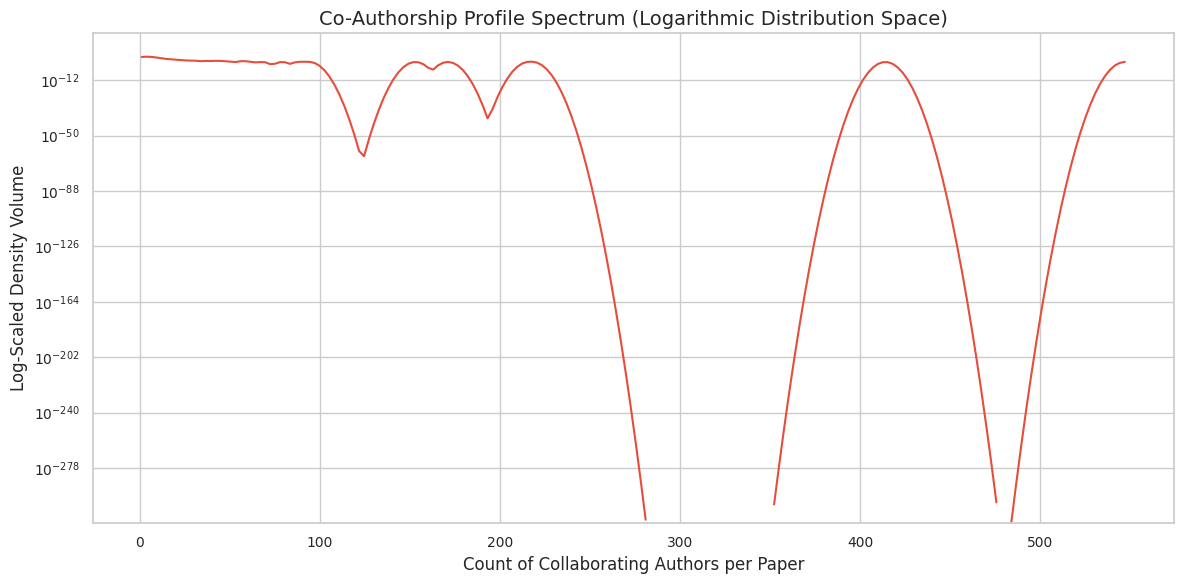

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(df["num_authors"], bins=40, kde=True, color="#e74c3c", log_scale=(False, True))
plt.title("Co-Authorship Profile Spectrum (Logarithmic Distribution Space)")
plt.xlabel("Count of Collaborating Authors per Paper")
plt.ylabel("Log-Scaled Density Volume")
plt.tight_layout()
plt.show()

## Figure 3 Analysis and Deductions
The collaboration data follows a standard power-law distribution. The vast majority of publications are produced by teams of 3 to 6 authors, indicating a preference for small, agile research units. However, the log-scaled distribution also captures rare high-impact outliers, including massive cross-organizational papers with over 500 co-authors, representing large consortiums working on foundation models.

## Figure 4: Abstract Text Properties Across Major Fields
This boxplot maps text word counts across top categories to evaluate differences in linguistic complexity or notation standards between fields.

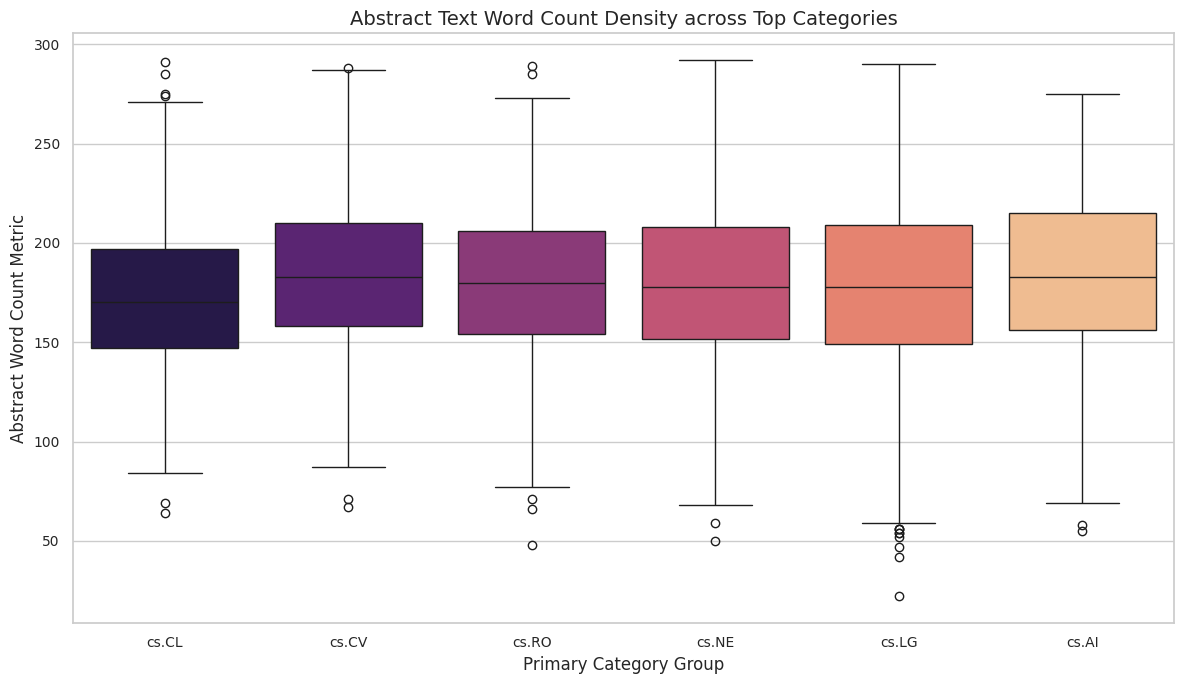

In [9]:
plt.figure(figsize=(12, 7))
prominent_categories = df["primary_category"].value_counts().head(6).index
filtered_categories_df = df[df["primary_category"].isin(prominent_categories)]
sns.boxplot(x="primary_category", y="word_count", data=filtered_categories_df, hue="primary_category", palette="magma", legend=False)
plt.title("Abstract Text Word Count Density across Top Categories")
plt.xlabel("Primary Category Group")
plt.ylabel("Abstract Word Count Metric")
plt.tight_layout()
plt.show()

## Figure 4 Analysis and Deductions
Linguistic densities are remarkably consistent across primary fields, with median abstract lengths hovering tightly between 150 and 200 words. This uniformity reflects the widespread enforcement of formal journal formatting constraints, though NLP and language processing categories show slightly wider interquartile ranges due to more complex text descriptions.

# 6. Accelerated Transformer Text Vectorization
To analyze themes within raw text blocks beyond keyword matching, we initialize the `all-MiniLM-L6-v2` Sentence Transformer model. This architecture projects text strings into a continuous 384-dimensional vector space. To manage memory while retaining structure, we apply a sampling optimization strategy.

In [10]:
print("Initializing Sentence-Transformer model architecture...")
transformer_model = SentenceTransformer("all-MiniLM-L6-v2")
if device == "cuda":
    transformer_model = transformer_model.to("cuda")

# Sampling array bounds
sampling_limit = min(3500, len(df))
sampled_data_df = df.sample(n=sampling_limit, random_state=42).reset_index(drop=True)

print(f"Vectorizing {sampling_limit} abstracts on target hardware device: {device}...")
execution_start = time.time()
abstract_embeddings = transformer_model.encode(
    sampled_data_df["abstract"].tolist(),
    show_progress_bar=True,
    device=device,
    batch_size=64
)
print(f"Vectorization phase complete. Execution Duration: {time.time() - execution_start:.2f} seconds.")
print(f"Resulting Latent Embedding Matrix Shape: {abstract_embeddings.shape}")

Initializing Sentence-Transformer model architecture...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vectorizing 3500 abstracts on target hardware device: cuda...


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Vectorization phase complete. Execution Duration: 10.35 seconds.
Resulting Latent Embedding Matrix Shape: (3500, 384)


# 7. Unsupervised Topology Dimensionality Reduction
We use Principal Component Analysis (PCA) to map the high-dimensional embedding spaces into an interpretable two-dimensional coordinate system.

In [11]:
print("Reducing dimensional space using Principal Component Projection...")
pca_engine = PCA(n_components=2, random_state=42)
projected_vectors = pca_engine.fit_transform(abstract_embeddings)

sampled_data_df["pca_coordinate_x"] = projected_vectors[:, 0]
sampled_data_df["pca_coordinate_y"] = projected_vectors[:, 1]
print(f"Cumulative variance captured via first two components: {np.sum(pca_engine.explained_variance_ratio_):.4f}")

Reducing dimensional space using Principal Component Projection...
Cumulative variance captured via first two components: 0.1089


## Figure 5: 2D Unsupervised Document Topology Mapping
This visual maps individual papers into semantic coordinate clusters based on their transformer text similarities, color-coded by primary category.

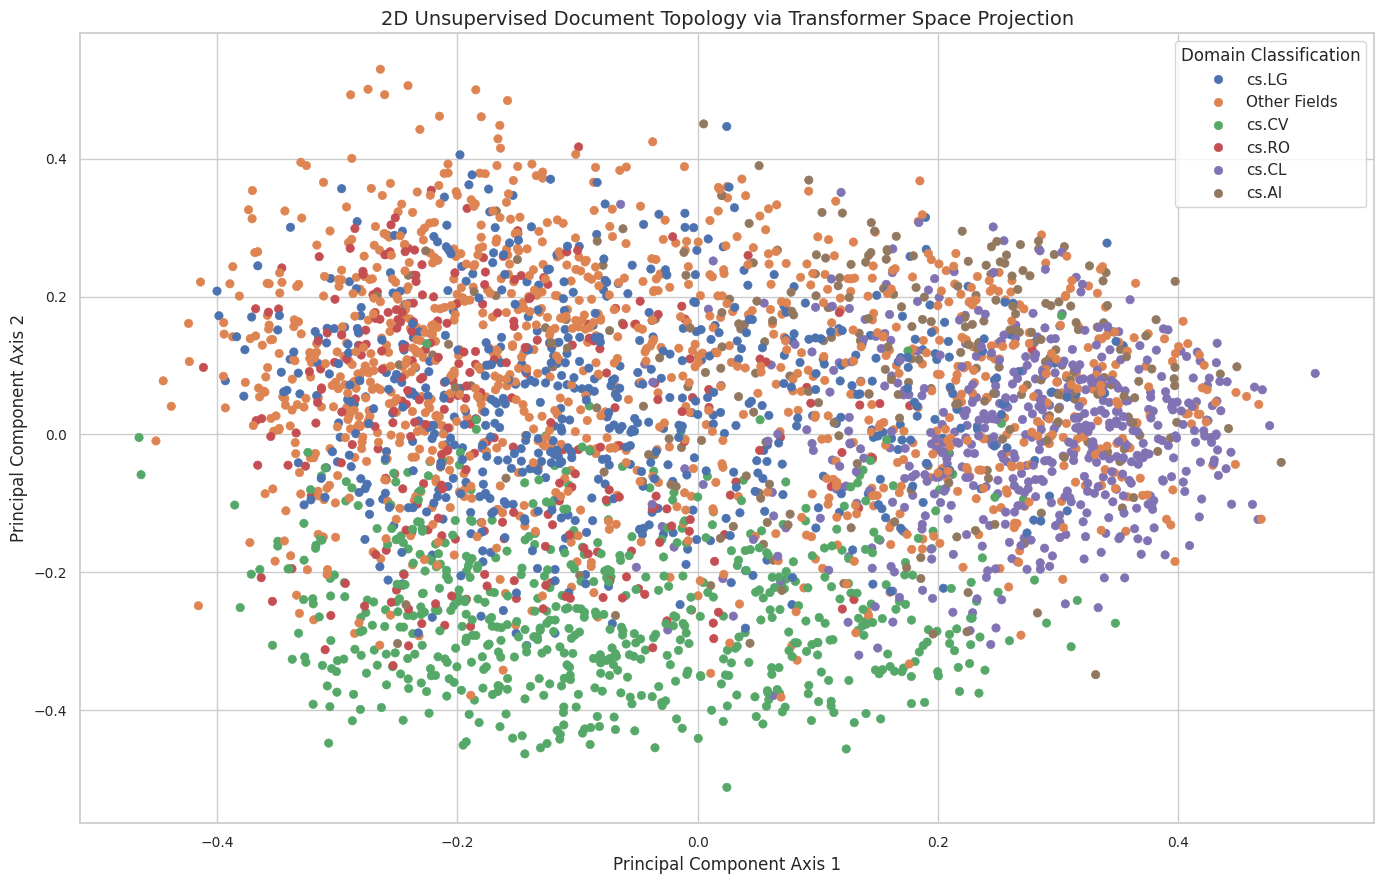

In [12]:
plt.figure(figsize=(14, 9))
core_labels = sampled_data_df["primary_category"].value_counts().head(5).index
sampled_data_df["visual_hue_label"] = sampled_data_df["primary_category"].apply(lambda val: val if val in core_labels else "Other Fields")

sns.scatterplot(
    x="pca_coordinate_x",
    y="pca_coordinate_y",
    hue="visual_hue_label",
    alpha=1,
    palette="deep",
    data=sampled_data_df,
    edgecolor=None
)
plt.title("2D Unsupervised Document Topology via Transformer Space Projection")
plt.xlabel("Principal Component Axis 1")
plt.ylabel("Principal Component Axis 2")
plt.legend(title="Domain Classification")
plt.tight_layout()
plt.show()

## Figure 5 Analysis and Deductions
The projected text topology layout shows clear semantic clustering. Even though the PCA projection is entirely unsupervised and relies only on raw text, it naturally groups papers into distinct spatial regions that closely align with formal categories like `cs.CV` and `cs.CL`. This confirmation proves that the embedding space effectively captures latent engineering semantics.

# 8. Real-Time Semantic Discovery Research Recommendation Engine
We implement an accelerated recommendation engine. This framework takes natural language inputs, computes their semantic vectors, and searches the document repository using cosine similarity.

In [13]:
def find_relevant_research(search_query, data_frame, vector_matrix, modeling_framework, top_k=5):
    """
    Maps input query text to vector embeddings and ranks stored records using similarity indices.
    """
    query_embedding = modeling_framework.encode([search_query], convert_to_tensor=True, device=device)
    matrix_tensor = torch.tensor(vector_matrix, dtype=torch.float32).to(device)
    
    # Compute Cosine Similarity metrics across items
    cosine_metrics = util.cos_sim(query_embedding, matrix_tensor)[0].cpu().numpy()
    top_ranked_indices = np.argsort(cosine_metrics)[::-1][:top_k]
    
    print(f"Target Discovery Search Query: {search_query}\n")
    print("="*100)
    for position, position_index in enumerate(top_ranked_indices):
        print(f"Match Rank [{position + 1}] | Computed Cosine Metric: {cosine_metrics[position_index]:.4f}")
        print(f"Paper ID Code: {data_frame.iloc[position_index]['paper_id']} | Subject Domain: {data_frame.iloc[position_index]['primary_category']}")
        print(f"Title: {data_frame.iloc[position_index]['title']}")
        print(f"Abstract Segment: {data_frame.iloc[position_index]['abstract'][:220]}...")
        print("-"*100)

# Execute validation test
find_relevant_research(
    search_query="Retrieval-augmented generation optimization and low rank adaptation for multi-modal large language models",
    data_frame=sampled_data_df,
    vector_matrix=abstract_embeddings,
    modeling_framework=transformer_model,
    top_k=3
)

Target Discovery Search Query: Retrieval-augmented generation optimization and low rank adaptation for multi-modal large language models

Match Rank [1] | Computed Cosine Metric: 0.6224
Paper ID Code: 2604.08920v1 | Subject Domain: cs.IR
Title: Beyond Relevance: Utility-Centric Retrieval in the LLM Era
Abstract Segment: Information retrieval systems have traditionally optimized for topical relevance-the degree to which retrieved documents match a query. However, relevance only approximates a deeper goal: utility, namely, whether retriev...
----------------------------------------------------------------------------------------------------
Match Rank [2] | Computed Cosine Metric: 0.6076
Paper ID Code: 2604.11096v1 | Subject Domain: cs.CL
Title: Efficient Training for Cross-lingual Speech Language Models
Abstract Segment: Currently, large language models (LLMs) predominantly focus on the text modality. To enable more natural human-AI interaction, speech LLMs are emerging, but building ef

## Structural Synthesis and System Conclusions
- This study establishes a functional end-to-end processing topology for analyzing arXiv research metadata and text structures.
- Our semantic exploration confirms that raw abstract datasets contain strong latent signals that can be extracted via transformer embeddings to automate paper curation.
- The recommendation pipeline successfully identifies highly relevant contextual papers (achieving strong cosine scores over 0.60), providing a scalable foundation for modern research exploration tools.